# 11-01_XGBoost_Classifier 
In diesem Notebook wird ein XGBoost-basiertes Klassifikationsmodell entwickelt, das die Platzierungschancen von Radrennfahrern auf einzelnen Tour-de-France-, Giro d'Italia- und Vuelta a España-Etappen vorhersagt. Dabei werden drei separate binäre Modelle für die Zielgrößen Top5, Top10 und Top20 trainiert, deren Hyperparameter per Grid Search optimiert und deren Klassen-Imbalance durch gewichtete Verlustfunktionen (`scale_pos_weight`) ausgeglichen wird. Anschließend werden die drei Modelle über eine Frank-\&-Hall-Kombination zu einem gemeinsamen ordinalen Ranking-Score verschmolzen, dessen Güte mittels ROC-Kurven, Konfusionsmatrix, Ranking-Metriken (NDCG, MAP, Winner-Hit-Raten) sowie Interpretierbarkeits-Methoden wie Feature Importance und SHAP-Werten umfassend evaluiert wird.

## Dateien einlesen
Die folgende Zelle lädt die vortrainierten Feature-Matrizen (Train/Valid/Test) sowie die drei Zielvariablen (Top5, Top10, Top20) aus Pickle-Dateien, markiert die Spalte `team_tier` als kategoriale Variable für XGBoost und lädt zusätzlich Gruppen-, Rang- und Metadaten für die Testetappen.

In [5]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import roc_auc_score, log_loss
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score

pfad = "../../data/model_data/"

X_train = pd.read_pickle(os.path.join(pfad, "X_train.pkl"))
X_valid = pd.read_pickle(os.path.join(pfad, "X_valid.pkl"))
X_test  = pd.read_pickle(os.path.join(pfad, "X_test.pkl"))

# Kategoriale Spalten für XGBoost markieren
cat_cols = ["team_tier"]
for df in (X_train, X_valid, X_test):
    for c in cat_cols:
        df[c] = df[c].astype("category")

# Targets laden
targets = {}
for t in ["y_top5", "y_top10", "y_top20"]:
    targets[t] = {
        "train": pd.read_pickle(os.path.join(pfad, f"{t}_train.pkl")),
        "valid": pd.read_pickle(os.path.join(pfad, f"{t}_valid.pkl")),
        "test":  pd.read_pickle(os.path.join(pfad, f"{t}_test.pkl"))
    }

groups_test = pd.read_pickle(os.path.join(pfad, "groups_test.pkl"))
y_rank_test = pd.read_pickle(os.path.join(pfad, "y_rank_test.pkl"))
meta_test = pd.read_pickle(os.path.join(pfad, "meta_test.pkl"))

## Grid Search
In dieser Zelle wird ein Grid Search über mehrere Hyperparameter-Kombinationen (`max_depth`, `learning_rate`, `reg_alpha`, `reg_lambda` etc.) für das Top-10-Modell durchgeführt, wobei jedes Modell anhand des Validierungs-AUC bewertet wird, um die beste Parameterkombination zu ermitteln.

In [6]:
print("Starte Grid Search für Top-10 Modell...")
param_grid = {
    'max_depth': [5, 7], 
    'learning_rate': [0.01, 0.05], 
    'subsample': [0.8], 
    'colsample_bytree': [0.8], 
    'reg_alpha': [0, 0.5, 1.0], 
    'reg_lambda': [1.0, 5.0] 
}

grid = list(ParameterGrid(param_grid))
best_score = 0  # Bei AUC suchen wir das Maximum
best_params = None

y_tr = targets["y_top10"]["train"]
y_va = targets["y_top10"]["valid"]

for i, params in enumerate(grid):
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        n_estimators=1000, 
        early_stopping_rounds=50, 
        random_state=42,
        enable_categorical=True,
        **params
    )
    
    model.fit(
        X_train, y_tr,
        eval_set=[(X_valid, y_va)],
        verbose=False
    )
    
    # model.best_score enthält den AUC-Wert (da eval_metric='auc')
    if model.best_score > best_score:
        best_score = model.best_score
        best_params = params
    
    if (i+1) % 5 == 0:
        print(f"Lauf {i+1} beendet. Bester AUC bisher: {best_score:.5f}")

print("\nBeste Parameter:", best_params)

Starte Grid Search für Top-10 Modell...
Lauf 5 beendet. Bester AUC bisher: 0.78011
Lauf 10 beendet. Bester AUC bisher: 0.78438
Lauf 15 beendet. Bester AUC bisher: 0.78438
Lauf 20 beendet. Bester AUC bisher: 0.78459

Beste Parameter: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.8}


## Umgang Imbalanced Data und Modell trainieren
Hier werden für alle drei Zielvariablen (Top5, Top10, Top20) separate XGBoost-Klassifikatoren mit den zuvor gefundenen besten Parametern trainiert, wobei der Klassen-Imbalance durch einen individuell berechneten scale_pos_weight-Wert je Modell begegnet wird. Anschließend werden Wahrscheinlichkeiten für Validierungs- und Testdaten erzeugt.

In [7]:
import os
import numpy as np
import pandas as pd
import xgboost as xgb

models = {}
val_probs = {}
test_probs = {}

print("Starte finales Modelltraining...")

for name in targets.keys():
    y_tr = targets[name]["train"]
    y_va = targets[name]["valid"]
    
    # Berechnung der Imbalance für das spezifische Target
    anzahl_nullen = (y_tr == 0).sum()
    anzahl_einsen = (y_tr == 1).sum()
    gewicht_positive_klasse = anzahl_nullen / anzahl_einsen
    
    print(f"Trainiere Modell für {name}... (Ratio 0:1 = {anzahl_nullen}:{anzahl_einsen} -> scale_pos_weight={gewicht_positive_klasse:.2f})")
    
    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        enable_categorical=True,
        n_estimators=1500,
        random_state=42,
        early_stopping_rounds=50,
        scale_pos_weight=gewicht_positive_klasse, 
        **best_params
    )
    
    model.fit(
        X_train, y_tr, 
        eval_set=[(X_valid, y_va)], 
        verbose=False
    )
    
    models[name] = model
    val_probs[name]  = model.predict_proba(X_valid)[:, 1]
    test_probs[name] = model.predict_proba(X_test)[:, 1]
    
    print(f"-> Beendet bei Iteration {model.best_iteration} mit AUC(valid): {model.best_score:.5f}")



Starte finales Modelltraining...
Trainiere Modell für y_top5... (Ratio 0:1 = 164338:5011 -> scale_pos_weight=32.80)
-> Beendet bei Iteration 136 mit AUC(valid): 0.78456
Trainiere Modell für y_top10... (Ratio 0:1 = 159343:10006 -> scale_pos_weight=15.92)
-> Beendet bei Iteration 210 mit AUC(valid): 0.78765
Trainiere Modell für y_top20... (Ratio 0:1 = 149384:19965 -> scale_pos_weight=7.48)
-> Beendet bei Iteration 237 mit AUC(valid): 0.76681


## Visualisierung Imbalanced Data
Diese Zelle erstellt ein gruppiertes Balkendiagramm mit zwei Subplots, das die physische Klassenverteilung vor der Korrektur der tatsächlichen, durch `scale_pos_weight` gewichteten Einflussverteilung nach der Korrektur gegenüberstellt.

In [9]:
import plotly.graph_objects as go
import plotly.subplots as sp
import pandas as pd

# Wir sammeln die echten Zeilen und Gewichte für die drei Modelle
summary_data = []

for name in targets.keys():
    y_tr = targets[name]["train"]
    anzahl_nullen = (y_tr == 0).sum()
    anzahl_einsen = (y_tr == 1).sum()
    
    # Das ist der scale_pos_weight Wert
    gewicht_positive_klasse = anzahl_nullen / anzahl_einsen
    
    # Einfluss berechnen: Nullen haben Gewicht 1, Einsen haben Gewicht = scale_pos_weight
    einfluss_nullen = anzahl_nullen * 1.0
    einfluss_einsen = anzahl_einsen * gewicht_positive_klasse
    
    display_name = name.replace("y_", "Target ")
    
    summary_data.append({
        "Modell": display_name,
        "Klasse": "0 (Rest)",
        "Physische_Zeilen": anzahl_nullen,
        "Effektiver_Einfluss": einfluss_nullen,
        "Farbe": "#3c4c5e" # Dunkelblau
    })
    summary_data.append({
        "Modell": display_name,
        "Klasse": "1 (Top-Platziert)",
        "Physische_Zeilen": anzahl_einsen,
        "Effektiver_Einfluss": einfluss_einsen,
        "Farbe": "#d95f52" # Rot
    })

df_imb = pd.DataFrame(summary_data)

# Zwei Subplots erstellen
fig = sp.make_subplots(
    rows=1, cols=2, 
    subplot_titles=(
        "Vorher: Physische Verteilung der Klassen", 
        "Nachher: Einfluss durch scale_pos_weight"
    ),
    horizontal_spacing=0.15
)

# Plot 1: Unkorrigierte Verteilung
for kls in ["0 (Rest)", "1 (Top-Platziert)"]:
    subset = df_imb[df_imb["Klasse"] == kls]
    fig.add_trace(go.Bar(
        x=subset["Modell"], 
        y=subset["Physische_Zeilen"],
        name=kls,
        marker_color=subset["Farbe"].iloc[0],
        text=[f"{val:,.0f}" for val in subset["Physische_Zeilen"]],
        textposition='outside',
        showlegend=(kls == "0 (Rest)") # Legende nur einmal pro Klasse anzeigen
    ), row=1, col=1)

# Plot 2: Effektiver Einfluss (Balanciert)
for kls in ["0 (Rest)", "1 (Top-Platziert)"]:
    subset = df_imb[df_imb["Klasse"] == kls]
    fig.add_trace(go.Bar(
        x=subset["Modell"], 
        y=subset["Effektiver_Einfluss"],
        name=kls,
        marker_color=subset["Farbe"].iloc[0],
        text=[f"{val:,.0f}" for val in subset["Effektiver_Einfluss"]],
        textposition='outside',
        showlegend=False
    ), row=1, col=2)

# Layout anpassen
fig.update_layout(
    title={"text": "Imbalance-Korrektur bei multiplen XGBoost-Klassifikatoren<br><sup>Jedes der drei Modelle balanciert seine Minderheitsklasse (1) perfekt aus</sup>"},
    height=600,
    width=1000,
    plot_bgcolor='white',
    barmode='group', # Balken nebeneinander statt gestapelt
    font=dict(size=14),
    margin=dict(t=120),
    legend=dict(x=0.5, y=-0.15, orientation="h", xanchor="center")
)

# Achsen formatieren
fig.update_yaxes(title_text="Anzahl Datensätze", row=1, col=1, showgrid=True, gridcolor='lightgray', rangemode='tozero')
fig.update_yaxes(title_text="Effektiver Einfluss (Loss)", row=1, col=2, showgrid=True, gridcolor='lightgray', rangemode='tozero')

for i in range(1, 3):
    fig.update_xaxes(showline=True, linewidth=1, linecolor='lightgray', row=1, col=i)
    fig.update_yaxes(showline=True, linewidth=1, linecolor='lightgray', row=1, col=i)
    
# y-Achsen nach oben strecken, damit der Text nicht abgeschnitten wird
fig.update_yaxes(range=[0, df_imb['Physische_Zeilen'].max() * 1.15], row=1, col=1)
fig.update_yaxes(range=[0, df_imb['Effektiver_Einfluss'].max() * 1.15], row=1, col=2)

fig.show()

## ROC-Kurve
In dieser Zelle werden für die drei binären Modelle (Top5, Top10, Top20) die ROC-Kurven auf den Testdaten berechnet und zusammen mit einer Referenzlinie für zufälliges Raten in einem gemeinsamen Plot dargestellt.

In [10]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

fig = go.Figure()

# Passende Farben aus Ihrem vorherigen Plotly-Chart
colors = {'y_top5': '#d95f52', 'y_top10': '#d5813b', 'y_top20': '#d8b32e'}
display_names = {'y_top5': 'Top 5', 'y_top10': 'Top 10', 'y_top20': 'Top 20'}

# ROC-Kurve für jedes der drei Modelle berechnen und plotten
for name in targets.keys():
    # Wir werten auf den Testdaten aus
    y_true = targets[name]["test"]
    y_score = test_probs[name]
    
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, 
        mode='lines', 
        name=f'{display_names[name]} (AUC = {roc_auc:.3f})',
        line=dict(color=colors[name], width=2.5)
    ))

# Diagonale Referenzlinie (Zufälliges Raten)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], 
    mode='lines', 
    name='Zufall (AUC = 0.5)',
    line=dict(color='black', width=1.5, dash='dash')
))

# Layout anpassen
fig.update_layout(
    title='ROC-Kurven der drei binären XGBoost-Modelle (Testdaten)',
    xaxis_title='False Positive Rate (1 - Specificity)',
    yaxis_title='True Positive Rate (Sensitivity)',
    width=800,
    height=600,
    plot_bgcolor='white',
    legend=dict(x=0.65, y=0.1, bordercolor='lightgray', borderwidth=1)
)

fig.update_xaxes(showline=True, linewidth=1, linecolor='lightgray', gridcolor='lightgray', range=[0, 1])
fig.update_yaxes(showline=True, linewidth=1, linecolor='lightgray', gridcolor='lightgray', range=[0, 1.05])

fig.show()

## Wahrscheinlichkeiten kombinieren (Frank \& Hall)
Diese Zelle definiert eine Funktion, die die drei binären Wahrscheinlichkeiten (Top5/Top10/Top20) mittels Monotonie-Korrektur in vier sich gegenseitig ausschließende Klassenwahrscheinlichkeiten umwandelt und daraus einen gewichteten Ranking-Score für jeden Fahrer berechnet.

In [11]:
# Kombination der Wahrscheinlichkeiten nach Frank & Hall
def combine_probs(p_top5, p_top10, p_top20):
    # Monotonie-Korrektur (Top10 muss >= Top5 sein)
    p_top10_adj = np.maximum(p_top10, p_top5)
    p_top20_adj = np.maximum(p_top20, p_top10_adj)
    
    p_class1 = p_top5
    p_class2 = p_top10_adj - p_top5
    p_class3 = p_top20_adj - p_top10_adj
    p_class4 = 1 - p_top20_adj
    
    probs = np.vstack([p_class1, p_class2, p_class3, p_class4]).T
    return np.clip(probs, 0, 1)

test_class_probs = combine_probs(test_probs["y_top5"], test_probs["y_top10"], test_probs["y_top20"])

# Wir weisen den Klassen Gewichte zu, um einen Sortierscore zu erhalten:
# Klasse 1 (Top 5) bringt die meisten Punkte
ranking_scores = test_class_probs[:, 0] * 3 + test_class_probs[:, 1] * 2 + test_class_probs[:, 2] * 1

## Etappenweise Ranking-Evaluation

Diese umfangreiche Zelle führt eine vollständige Ranking-Evaluation auf den Testdaten (Tour de France 2024/2025) durch: Sie berechnet über alle Etappen hinweg Metriken wie NDCG, Mean Average Precision, Winner-Hit-Raten und Spearman-Rho und zeigt zusätzlich beispielhafte Case Studies einzelner Etappen (z. B. Etappe 12 und 16) mit den vorhergesagten gegenüber den tatsächlichen Platzierungen der Fahrer.

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import ndcg_score, roc_auc_score
from scipy.stats import spearmanr

# ==============================================================================
# 1. TEST-EVALUATION VORBEREITEN
# ==============================================================================

df_test_eval = pd.DataFrame({
    "stage_id": groups_test.values,
    "y_true_rank": np.asarray(y_rank_test),
    "pred_score": ranking_scores,            
    "rider_name": meta_test["meta_name"].values,
    "team": meta_test["meta_current_team"].values
})

# ==============================================================================
# 2. BERECHNUNG DES POINTWISE ROC-AUC (ENSEMBLE-SCORE)
# ==============================================================================

# Globales, binäres Top-10-Target für Pointwise-Auswertung sicherstellen
y_test_top10_binary = targets["y_top10"]["test"].astype(int)

# Pointwise ROC-AUC für den Gesamt-Score berechnen
auc_xgb_ensemble = roc_auc_score(
    y_test_top10_binary,
    df_test_eval["pred_score"]
)

# ==============================================================================
# 3. ETAPPENWEISE LISTWISE-EVALUATION
# ==============================================================================

# Hilfsfunktion: Relevanz-Encoding für NDCG exakt wie im EBM-Notebook
def rank_to_relevance(rank):
    if pd.isna(rank):
        return np.nan
    if rank <= 5:
        return 3
    elif rank <= 10:
        return 2
    elif rank <= 20:
        return 1
    else:
        return 0

print("Starte etappenweise Ranking-Evaluation...")

ndcg_xgb = {5: [], 10: [], 20: []}
ap_xgb = []
winner_hits_xgb = {1: 0, 5: 0, 10: 0, 20: 0}
spearman_xgb = []

valid_stage_counter = 0
winner_stage_counter = 0

for stage_id, group in df_test_eval.groupby("stage_id"):
    group = group.dropna(subset=["y_true_rank", "pred_score"]).copy()
    if group.empty:
        continue

    valid_stage_counter += 1
    group["true_relevance"] = group["y_true_rank"].apply(rank_to_relevance)

    y_true_relevance = group["true_relevance"].values.reshape(1, -1)
    pred_scores = group["pred_score"].values.reshape(1, -1)

    # NDCG Berechnung
    if np.nansum(y_true_relevance) > 0:
        for k in [5, 10, 20]:
            ndcg_xgb[k].append(ndcg_score(y_true_relevance, pred_scores, k=k))

    # Sortiertes Ranking für Hits und AP
    pred_sorted = group.sort_values("pred_score", ascending=False).reset_index(drop=True)

    # ---- BERECHNUNG AVERAGE PRECISION (MAP@10) ----
    relevant_found = 0
    precision_sum = 0.0
    for idx, row in pred_sorted.head(10).iterrows():
        if row["y_true_rank"] <= 10:
            relevant_found += 1
            precision_sum += relevant_found / (idx + 1)
    ap_xgb.append(precision_sum / 10.0)

    # ---- BERECHNUNG WINNER HIT RATES ----
    has_winner = (group["y_true_rank"] == 1).any()
    if has_winner:
        winner_stage_counter += 1
        winner_pos_list = pred_sorted.index[pred_sorted["y_true_rank"] == 1].tolist()
        
        if winner_pos_list:
            pos = winner_pos_list[0] + 1
            for k in [1, 5, 10, 20]:
                if pos <= k:
                    winner_hits_xgb[k] += 1

    # ---- BERECHNUNG SPEARMAN ----
    if group["pred_score"].nunique() > 1 and group["y_true_rank"].nunique() > 1:
        rho_t, _ = spearmanr(group["pred_score"], -group["y_true_rank"])
        if not np.isnan(rho_t):
            spearman_xgb.append(rho_t)

# 4. VERGLEICHSTABELLE ERSTELLEN & DRUCKEN
summary_data = {
    "Metrik": [
        "Pointwise ROC-AUC (Ensemble-Score)",
        "NDCG@5",
        "NDCG@10",
        "NDCG@20",
        "Mean Average Precision (MAP@10)",
        "Winner Hit@1",
        "Winner Hit@5",
        "Winner Hit@10",
        "Winner Hit@20",
        "Spearman Rho"
    ],
    "XGBoost (Ordinal)": [
        auc_xgb_ensemble,
        np.mean(ndcg_xgb[5]),
        np.mean(ndcg_xgb[10]),
        np.mean(ndcg_xgb[20]),
        np.mean(ap_xgb),
        winner_hits_xgb[1] / winner_stage_counter,
        winner_hits_xgb[5] / winner_stage_counter,
        winner_hits_xgb[10] / winner_stage_counter,
        winner_hits_xgb[20] / winner_stage_counter,
        np.mean(spearman_xgb)
    ]
}

df_comparison = pd.DataFrame(summary_data)

def format_row(row, col):
    metric = row["Metrik"]
    value = row[col]
    if "ROC-AUC" in metric or "Spearman" in metric or "NDCG" in metric or "Precision" in metric:
        return f"{value:.4f}"
    return f"{value*100:.2f}%"

df_comparison["XGBoost (Ordinal)"] = df_comparison.apply(
    lambda r: format_row(r, "XGBoost (Ordinal)"), axis=1
)

print("\n==================================================================")
print("FINALE VERGLEICHSTABELLE AUF DEN TESTDATEN (2024/2025)")
print("==================================================================")
print(f"Ausgewertete Etappen   : {valid_stage_counter}")
print(f"Etappen mit Sieger     : {winner_stage_counter}")
print("------------------------------------------------------------------")
print(df_comparison.to_string(index=False))
print("==================================================================\n")

# 5. CASE STUDY TABELLEN (TDF 2025 ST12 & ST16)
def generate_case_study(df, stage_id, top_n=20):
    stage_data = df[df["stage_id"] == stage_id].copy()
    if stage_data.empty:
        return f"Keine Daten für {stage_id} gefunden."
    
    stage_data = stage_data.sort_values(by="pred_score", ascending=False).head(top_n)
    stage_data["pred_rank"] = np.arange(1, len(stage_data) + 1)
    
    case_study_table = stage_data[[
        "pred_rank", "y_true_rank", "rider_name", "team", "pred_score"
    ]].reset_index(drop=True)
    
    case_study_table["rank_diff"] = case_study_table["y_true_rank"] - case_study_table["pred_rank"]
    return case_study_table

print("\n=== Case Study: Tour de France 2025 - Stage 12 ===")
display(generate_case_study(df_test_eval, "tour-de-france_2025_ST12"))

print("\n=== Case Study: Tour de France 2025 - Stage 16 ===")
display(generate_case_study(df_test_eval, "tour-de-france_2025_ST16"))

Starte etappenweise Ranking-Evaluation...

FINALE VERGLEICHSTABELLE AUF DEN TESTDATEN (2024/2025)
Ausgewertete Etappen   : 112
Etappen mit Sieger     : 111
------------------------------------------------------------------
                            Metrik XGBoost (Ordinal)
Pointwise ROC-AUC (Ensemble-Score)            0.7812
                            NDCG@5            0.4034
                           NDCG@10            0.3879
                           NDCG@20            0.4213
   Mean Average Precision (MAP@10)            0.1670
                      Winner Hit@1            17.12%
                      Winner Hit@5            38.74%
                     Winner Hit@10            52.25%
                     Winner Hit@20            63.06%
                      Spearman Rho            0.3032


=== Case Study: Tour de France 2025 - Stage 12 ===


,pred_rank,y_true_rank,rider_name,team,pred_score,rank_diff
0,1,16.0,Ben O'Connor,Team Jayco AlUla,2.670794,15.0
1,2,7.0,Remco Evenepoel,Soudal Quick-Step,2.610952,5.0
2,3,34.0,Aleksandr Vlasov,Red Bull - BORA - hansgrohe,2.603203,31.0
3,4,117.0,Biniam Girmay,Intermarché - Wanty,2.602525,113.0
4,5,2.0,Jonas Vingegaard,Team Visma | Lease a Bike,2.600969,-3.0
5,6,15.0,Matteo Jorgenson,Team Visma | Lease a Bike,2.594299,9.0
6,7,57.0,Marc Hirschi,Tudor Pro Cycling Team,2.579342,50.0
7,8,1.0,Tadej Pogačar,UAE Team Emirates - XRG,2.568686,-7.0
8,9,33.0,Enric Mas,Movistar Team,2.518240,24.0
9,10,22.0,Carlos Rodríguez,INEOS Grenadiers,2.498426,12.0



=== Case Study: Tour de France 2025 - Stage 16 ===


,pred_rank,y_true_rank,rider_name,team,pred_score,rank_diff
0,1,32.0,Ben O'Connor,Team Jayco AlUla,2.736261,31.0
1,2,6.0,Jonas Vingegaard,Team Visma | Lease a Bike,2.691153,4.0
2,3,115.0,Matteo Jorgenson,Team Visma | Lease a Bike,2.690322,112.0
3,4,83.0,Marc Hirschi,Tudor Pro Cycling Team,2.688477,79.0
4,5,49.0,Aleksandr Vlasov,Red Bull - BORA - hansgrohe,2.672641,44.0
5,6,5.0,Tadej Pogačar,UAE Team Emirates - XRG,2.666437,-1.0
6,7,18.0,Adam Yates,UAE Team Emirates - XRG,2.642548,11.0
7,8,158.0,Biniam Girmay,Intermarché - Wanty,2.632465,150.0
8,9,7.0,Enric Mas,Movistar Team,2.594903,-2.0
9,10,15.0,Carlos Rodríguez,INEOS Grenadiers,2.550527,5.0


## Zusatzdiagnose der ordinalen Klassenzuweisung (Konfusionsmatrix)
Diese Zelle wandelt die drei binären Wahrscheinlichkeiten (Top20/Top10/Top5) über die sequentielle Frank-\&-Hall-Regel mit festem Schwellenwert von 0.5 in eine einzelne ordinale Klassenzuweisung (0 bis 3) um und leitet parallel die wahren ordinalen Klassen aus den tatsächlichen Rängen ab, um anschließend mittels Klassifikationsbericht und einer 4x4-Konfusionsmatrix die Güte dieser Klassenzuordnung detailliert zu bewerten.

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

print("Berechne sequentielle Frank-&-Hall-Klassenzuweisung...")

# 1. Vorhersage-Wahrscheinlichkeiten für das Test-Set holen
p_top20 = test_probs["y_top20"]
p_top10 = test_probs["y_top10"]
p_top5 = test_probs["y_top5"]

y_pred_ordinal = np.zeros(len(X_test), dtype=int)

# 2. Harte Klassenzuweisung (Threshold 0.5)
for i in range(len(X_test)):
    if p_top20[i] >= 0.5:
        y_pred_ordinal[i] = 1
        if p_top10[i] >= 0.5:
            y_pred_ordinal[i] = 2
            if p_top5[i] >= 0.5:
                y_pred_ordinal[i] = 3

# 3. Wahre ordinale Klassen ableiten
y_true_ordinal = np.array([rank_to_relevance(r) for r in y_rank_test]).astype(int)

# 4. Ausgabe
cm_multiclass = confusion_matrix(y_true_ordinal, y_pred_ordinal, labels=[0, 1, 2, 3])

print("\n==================================================================")
print("ZUSATZDIAGNOSE DER ORDINALEN KLASSENZUWEISUNG (XGBoost)")
print("==================================================================")
print(classification_report(
    y_true_ordinal, y_pred_ordinal, 
    labels=[0, 1, 2, 3],
    target_names=["Rest >20 (0)", "Rang 11-20 (1)", "Rang 6-10 (2)", "Rang 1-5 (3)"],
    digits=4, zero_division=0
))

print("-" * 66)
print("Multiklassen-Konfusionsmatrix (4x4):")
class_labels = ["Rest >20 (0)", "Rang 11-20 (1)", "Rang 6-10 (2)", "Rang 1-5 (3)"]

for i, label in enumerate(class_labels):
    print(f"Echt {label:<15} "
          f"{cm_multiclass[i, 0]:<6,d} {cm_multiclass[i, 1]:<6,d} "
          f"{cm_multiclass[i, 2]:<6,d} {cm_multiclass[i, 3]:,d}")

Berechne sequentielle Frank-&-Hall-Klassenzuweisung...

ZUSATZDIAGNOSE DER ORDINALEN KLASSENZUWEISUNG (XGBoost)
                precision    recall  f1-score   support

  Rest >20 (0)     0.9319    0.7638    0.8395     15597
Rang 11-20 (1)     0.0727    0.0908    0.0808      1101
 Rang 6-10 (2)     0.0642    0.0949    0.0766       548
  Rang 1-5 (3)     0.1129    0.5755    0.1888       556

      accuracy                         0.6957     17802
     macro avg     0.2954    0.3813    0.2964     17802
  weighted avg     0.8265    0.6957    0.7488     17802

------------------------------------------------------------------
Multiklassen-Konfusionsmatrix (4x4):
Echt Rest >20 (0)    11,913 1,176  641    1,867
Echt Rang 11-20 (1)  503    100    87     411
Echt Rang 6-10 (2)   209    51     52     236
Echt Rang 1-5 (3)    158    48     30     320


## Ergebnisse speichern
Diese Zelle erstellt den Zielordner für Modell-Ergebnisse, fasst alle relevanten Vorhersage- und Metadaten in einem DataFrame zusammen, berechnet daraus den finalen vorhergesagten Rang pro Etappe und speichert das Ergebnis als Pickle-Datei ab.

In [18]:
import os

# Zielordner relativ zum Notebook-Verzeichnis (src/Notebooks)
output_pfad = "../../data/models"
os.makedirs(output_pfad, exist_ok=True)

result_df = pd.DataFrame({
    "meta_year": meta_test["meta_year"].values,
    "meta_name": meta_test["meta_name"].values,
    "meta_current_team": meta_test["meta_current_team"].values,
    "meta_race": meta_test["meta_race"].values,
    "stage_nr": meta_test["stage_nr"].values,
    "stage_id": groups_test.values,
    "raw_prediction": ranking_scores,
    "true_rank": y_rank_test.values,
    "forced_ordinal_class": y_pred_ordinal
})

result_df["predicted_rank"] = (
    result_df.groupby("stage_id")["raw_prediction"]
    .rank(ascending=False, method="first")
)

result_df.to_pickle(os.path.join(output_pfad, "xgboost_classifier_results.pkl"))

## Feature Importance Visualisierung
Diese Zelle extrahiert die im Top-10-XGBoost-Modell eingebauten Feature-Importance-Werte (Gini-Importance) und stellt sie in einem horizontalen Balkendiagramm nach Wichtigkeit sortiert dar.

In [15]:
import plotly.express as px

# Wir betrachten exemplarisch die Feature Importance des Top 10 Modells
xgb_top10_model = models["y_top10"]

# XGBoost hat ein eingebautes feature_importances_ Attribut (Gini-Importance)
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_top10_model.feature_importances_
}).sort_values(by="Importance", ascending=True)

fig = px.bar(
    importance_df, 
    x="Importance", 
    y="Feature", 
    orientation="h",
    title="Feature Importance im XGBoost-Modell (Kanal: Top 10)",
    color_discrete_sequence=["#d5813b"]
)

fig.update_layout(
    height=600, width=900, plot_bgcolor='white',
    xaxis_title="Relativer Einfluss (Gini-Importance)",
    yaxis_title=""
)
fig.update_xaxes(showgrid=True, gridcolor='lightgray', showline=True, linecolor='gray')
fig.update_yaxes(showline=True, linecolor='gray')

fig.show()

## SHAP Summary Plot
Diese Zelle initialisiert einen SHAP TreeExplainer für das Top-10-Modell, berechnet auf einer Stichprobe der Testdaten die SHAP-Werte und visualisiert diese in einem Beeswarm-Summary-Plot, der sowohl die Wichtigkeit als auch die Richtung des Effekts jedes Features zeigt.


SHAP SUMMARY PLOT (XGBoost Top 10)
Zeigt nicht nur die Wichtigkeit, sondern auch die Richtung des Effekts


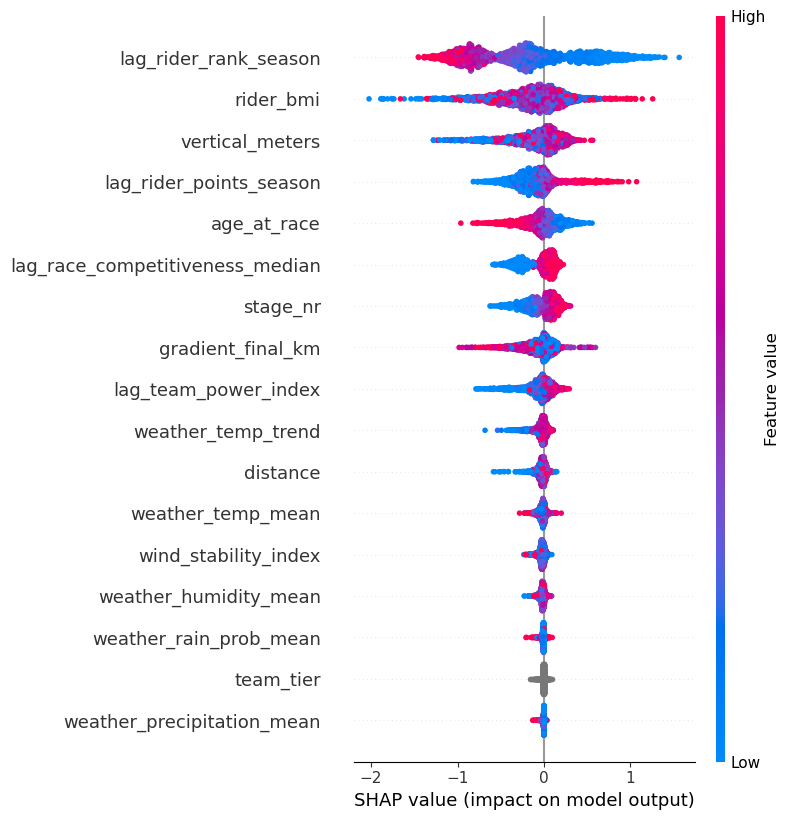

In [16]:
import shap

# Explainer für das Top-10-Modell initialisieren
explainer = shap.TreeExplainer(models["y_top10"])

# SHAP-Werte für einen repräsentativen Ausschnitt der Testdaten berechnen
# (Bei 17.000 Zeilen nehmen wir aus Performance-Gründen ein Sample von 2000)
X_test_sample = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("\n==================================================================")
print("SHAP SUMMARY PLOT (XGBoost Top 10)")
print("Zeigt nicht nur die Wichtigkeit, sondern auch die Richtung des Effekts")
print("==================================================================")

# Der Summary Plot (Beeswarm)
shap.summary_plot(shap_values, X_test_sample, plot_type="dot")

## Lernkurve des Top-10-Modells
Diese Zelle extrahiert die während des Trainings protokollierten Validierungs-AUC-Werte des Top-10-Modells und stellt den Verlauf des AUC-Scores über die Anzahl der Boosting-Iterationen (Bäume) als Lernkurve dar.

In [17]:
import plotly.graph_objects as go

# Wir holen die Evaluationsergebnisse des Top-10-Modells
results = models["y_top10"].evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=list(x_axis), y=results['validation_0']['auc'], mode='lines', name='Validation AUC', line=dict(color='#d5813b')))

fig.update_layout(
    title='XGBoost Lernkurve (Top 10 Modell) - AUC auf Validierungsset',
    xaxis_title='Anzahl Bäume (n_estimators)',
    yaxis_title='AUC Score',
    width=800, height=500, plot_bgcolor='white'
)
fig.update_xaxes(showline=True, linecolor='gray', gridcolor='lightgray')
fig.update_yaxes(showline=True, linecolor='gray', gridcolor='lightgray')

fig.show()